# Искусственная нейронная сеть

В лекции алгоритмы демонстрировались на искусственно созданных линейно разделимых данных. В данной работе используется датасет **Iris**:

- **Персептрон и ADALINE** — два класса: setosa и versicolor (два признака: длина и ширина лепестка). Эти классы линейно разделимы.
- **MLP** — два класса: versicolor и virginica (те же два признака). Эти классы линейно неразделимы, поэтому персептрон не справляется, а MLP — справляется.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
clrs = ['C0', 'C1']
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
from sklearn.neural_network import MLPClassifier
from scipy.special import expit

iris = load_iris()

## Персептрон Розенблатта

### Данные: setosa vs versicolor

Выберем два класса (setosa и versicolor) и два признака (длина и ширина лепестка). Метки классов преобразуем из $\{0, 1\}$ в $\{-1, +1\}$, как в лекции.

In [2]:
mask = iris.target < 2
X_train = iris.data[mask][:, 2:4]  # длина и ширина лепестка
y_train = np.where(iris.target[mask] == 0, -1, 1)

print('Размер выборки:', X_train.shape)
print('Классы:', np.unique(y_train))

Размер выборки: (100, 2)
Классы: [-1  1]


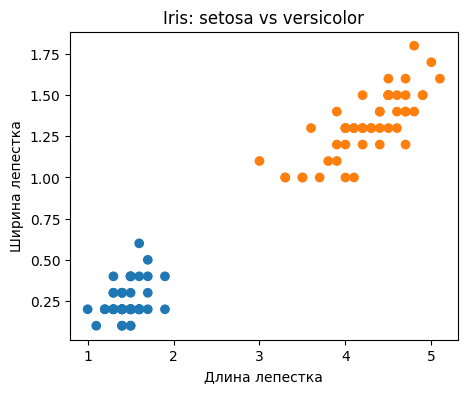

In [3]:
plt.figure(figsize=(5, 4))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
            cmap=colors.ListedColormap(clrs))
plt.xlabel('Длина лепестка')
plt.ylabel('Ширина лепестка')
plt.title('Iris: setosa vs versicolor')
plt.show()

Создадим класс Perceptron.

In [4]:
class Perceptron:

  def __init__(self, eta=0.01, epochs=50, const=0):
    self.eta = eta
    self.const = const
    self.epochs = epochs
    self.w = None

  def fit(self, X, y):

    X = np.c_[np.ones((len(X), 1)), X]
    # константа добавляется для вычислительной устойчивости
    self.w = np.zeros(X.shape[1]) + self.const

    for _ in range(self.epochs):
      for xi, target in zip(X, y):
        delta = self.eta * (target - np.where(np.dot(xi, self.w) > .0, 1, -1))
        self.w += delta * xi

    return self

  def predict(self, X):
    X = np.c_[np.ones((len(X), 1)), X]
    scores = np.dot(X, self.w)
    y_pred = np.where(np.dot(X, self.w) > .0, 1, -1)
    return y_pred, scores

Обучим однослойный персептрон.

In [5]:
slp = Perceptron().fit(X_train, y_train)
accuracy_score(y_train, slp.predict(X_train)[0])

1.0

Посмотрим на решающую границу.

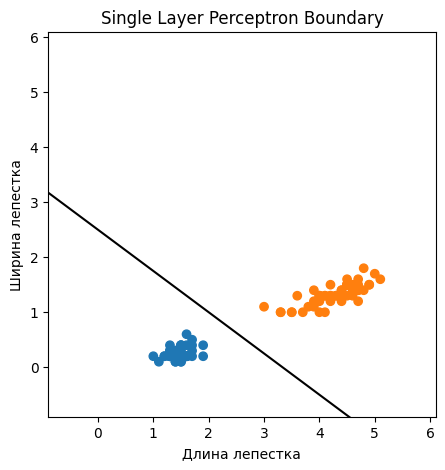

In [6]:
def plot_data(X, y, title, w=None, b=None, ticks=None):
  plt.figure(figsize=(5, 5))
  plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
              cmap=colors.ListedColormap(clrs))

  ax_min, ax_max = min(X_train.ravel() - 1), max(X_train.ravel() + 1)
  xx = np.linspace(ax_min, ax_max)

  hyperplane_slope = -w[0]/w[1]
  hyperplane_intercept = -b/w[1]
  yy = hyperplane_slope*xx + hyperplane_intercept
  hyperplane = np.array(list(zip(xx, yy)))
  plt.plot(hyperplane[:, 0], hyperplane[:, 1], 'k-')

  if ticks != None:
    plt.xticks(ticks)
    plt.yticks(ticks)
  plt.xlim(ax_min, ax_max)
  plt.ylim(ax_min, ax_max)
  plt.title(title)
  plt.xlabel('Длина лепестка')
  plt.ylabel('Ширина лепестка')
  plt.show()

plot_data(X_train, y_train, title='Single Layer Perceptron Boundary',
          w=slp.w[1:], b=slp.w[0])

## Адаптивный линейный нейрон

Заменим функцию Хевисайда на линейную функцию и воспользуемся дельта-правилом.

Full-batch gradient descent

In [7]:
class AdalineGD:

  def __init__(self, eta=0.01, epochs=50):
    self.eta = eta
    self.epochs = epochs
    self.w = None
    self.loss_history = []

  def fit(self, X, y):

    X = np.c_[np.ones((len(X), 1)), X]
    self.w = np.zeros(X.shape[1])

    for i in range(self.epochs):
      errors = (y - np.dot(X, self.w))
      self.w += self.eta * X.T.dot(errors)
      loss = (errors**2).sum() / 2
      self.loss_history.append(loss)

    return self

  def predict(self, X):
    X = np.c_[np.ones((len(X), 1)), X]
    y_pred = np.where(np.dot(X, self.w) > .0, 1, -1)

    return y_pred

In [8]:
adaline_gd = AdalineGD().fit(X_train, y_train)
accuracy_score(y_train, adaline_gd.predict(X_train))

0.5

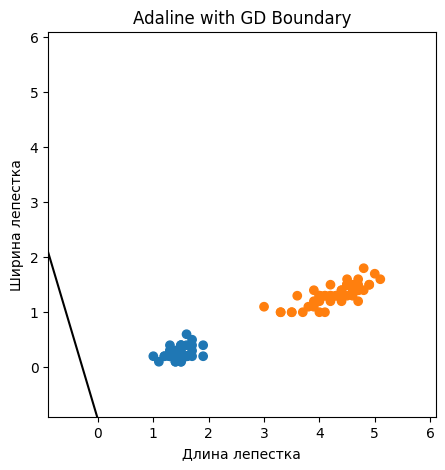

In [9]:
plot_data(X_train, y_train, title='Adaline with GD Boundary',
          w=adaline_gd.w[1:], b=adaline_gd.w[0])

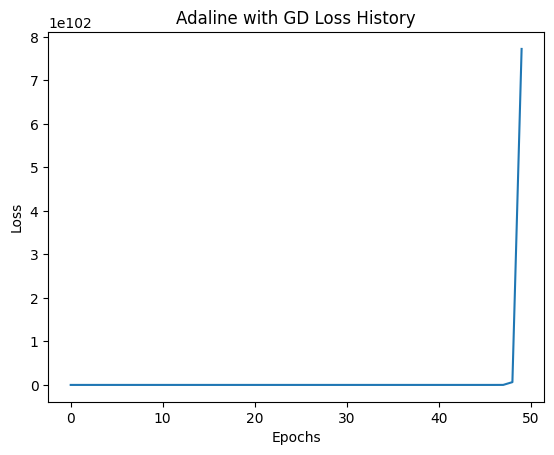

In [10]:
plt.plot(adaline_gd.loss_history)
plt.title('Adaline with GD Loss History')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

Выше мы обновляли веса на основе всех объектов обучающей выборки (full-batch gradient descent).

Обновлять параметры можно после предъявления одного (случайного) объекта. В этом случае речь идет о стохастическом градиентном спуске (stochastic gradient descent, SGD).

Stochastic gradient descent

In [11]:
class AdalineSGD:

  def __init__(self, eta=0.01, epochs=50):
    self.eta = eta
    self.epochs = epochs
    self.w = None
    self.loss_history = []

  def fit(self, X, y):

    X = np.c_[np.ones((len(X), 1)), X]
    self.w = np.zeros(X.shape[1])

    for i in range(self.epochs):
      for xi, yi in zip(X,y):
        errors = (yi - np.dot(xi, self.w))
        self.w += self.eta * xi.T.dot(errors)

      loss = ((y - np.dot(X, self.w))**2).sum() / 2
      self.loss_history.append(loss)

    return self

  def predict(self, X):
    X = np.c_[np.ones((len(X), 1)), X]
    y_pred = np.where(np.dot(X, self.w) > .0, 1, -1)

    return y_pred

In [12]:
adaline_sgd = AdalineSGD().fit(X_train, y_train)
accuracy_score(y_train, adaline_sgd.predict(X_train))

1.0

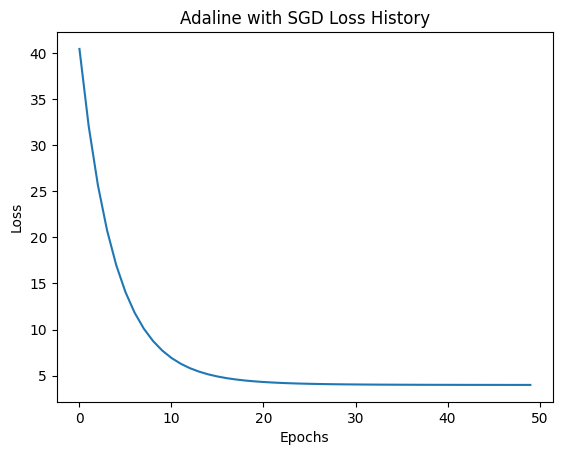

In [13]:
plt.plot(adaline_sgd.loss_history)
plt.title('Adaline with SGD Loss History')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

## Линейно неразделимые данные

Помимо ширины зазора ещё одним ограничением персептрона Розенблатта является невозможность найти границу линейно неразделимых данных.

Возьмём два других класса Iris — versicolor и virginica (те же два признака). Эти классы частично перекрываются и не являются линейно разделимыми.

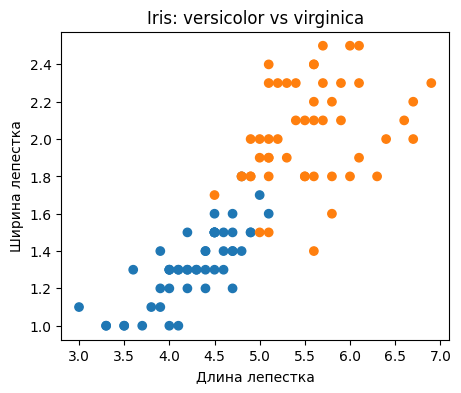

In [14]:
mask2 = iris.target > 0
X_train = iris.data[mask2][:, 2:4]
y_train = np.where(iris.target[mask2] == 1, -1, 1)

plt.figure(figsize=(5, 4))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
            cmap=colors.ListedColormap(clrs))
plt.xlabel('Длина лепестка')
plt.ylabel('Ширина лепестка')
plt.title('Iris: versicolor vs virginica')
plt.show()

Проверим, что однослойный персептрон не справляется с этими данными.

In [15]:
slp2 = Perceptron().fit(X_train, y_train)
accuracy_score(y_train, slp2.predict(X_train)[0])

0.5

### Многослойный персептрон

Создадим классификатор на основе многослойного персептрона с помощью класса MLPClassifier библиотеки sklearn.

In [16]:
# для MLP используем метки 0/1
y_train_mlp = np.where(iris.target[mask2] == 1, 0, 1)

mlp = MLPClassifier(hidden_layer_sizes=(2),
                    # будем использовать сигмоиду в качестве
                    # функции активации
                    activation='logistic',
                    solver='lbfgs',
                    random_state=1).fit(X_train, y_train_mlp)

In [17]:
accuracy_score(y_train_mlp, mlp.predict(X_train))

0.94

Посмотрим на нелинейную решающую границу на исходном представлении данных (data representation).

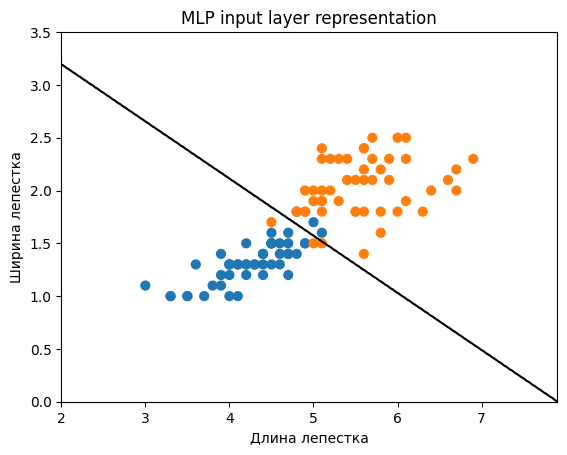

In [18]:
plt.scatter(X_train[:, 0], X_train[:, 1],
            c=y_train_mlp, s=40, cmap=colors.ListedColormap(clrs))

x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
XX, YY = np.meshgrid(np.linspace(x_min, x_max, 1000),
                     np.linspace(y_min, y_max, 1000))
Z = mlp.predict(np.c_[XX.ravel(), YY.ravel()])
Z = Z.reshape(XX.shape)
plt.contour(XX, YY, Z, levels=[0], colors=['k'])

plt.title('MLP input layer representation')
plt.xlabel('Длина лепестка')
plt.ylabel('Ширина лепестка')
plt.show()

Кроме этого, в данном случае мы можем посмотреть, какому представлению данных обучились нейроны скрытого слоя.

Скрытое представление данных

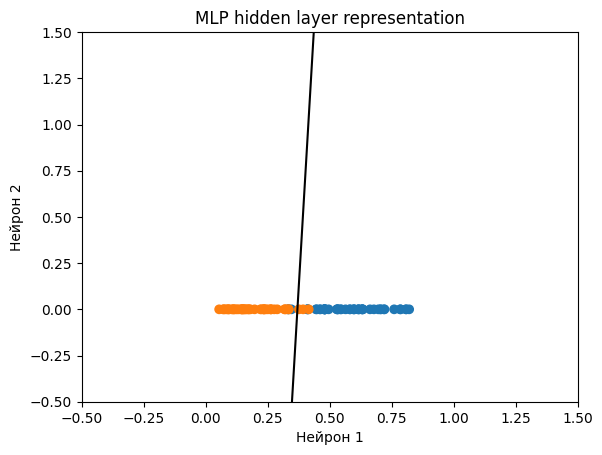

In [19]:
# умножим веса первого слоя на матрицу данных, добавим смещение и
# пропустим через сигмоиду
hidden = expit(np.dot(X_train, mlp.coefs_[0]) + mlp.intercepts_[0])

plt.scatter(hidden[:, 0], hidden[:, 1], c=y_train_mlp,
            cmap=colors.ListedColormap(clrs))

hyperplane_slope = -mlp.coefs_[1][0]/mlp.coefs_[1][1]
hyperplane_intercept = -mlp.intercepts_[1]/mlp.coefs_[1][1]

ax_min, ax_max = -.5, 1.5
xx = np.linspace(ax_min, ax_max)
yy = hyperplane_slope*xx + hyperplane_intercept
hyperplane = np.array(list(zip(xx, yy)))
plt.plot(hyperplane[:, 0], hyperplane[:, 1], 'k-')

plt.xlim(ax_min, ax_max)
plt.ylim(ax_min, ax_max)
plt.title('MLP hidden layer representation')
plt.xlabel('Нейрон 1')
plt.ylabel('Нейрон 2')
plt.show()